# Sesión 4: Redes Neuronales Convolucionales (CNN)
Guido Anthony Chipana Calderon

---

### Objetivos de la sesión:
1. Entender por qué CNNs son ideales para visión computacional
2. Implementar operaciones de convolución desde cero con NumPy
3. Comprender padding, stride, y pooling matemáticamente
4. Visualizar filtros y feature maps aprendidos
5. Construir arquitecturas CNN modernas en PyTorch
6. Entrenar CNNs en CIFAR-10 con data augmentation
7. Dominar Transfer Learning con modelos pre-entrenados
8. Implementar Fine-tuning y análisis de resultados

---

## PARTE 1: Configuración del Entorno
### 1.1 Verificación de GPU

In [ ]:
!nvidia-smi

Tue Feb 24 03:56:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1.2 Montaje de Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_PATH = '/content/drive/MyDrive/curso_cv'
OUTPUT_PATH = f'{BASE_PATH}/outputs/sesion4'
MODELS_PATH = f'{BASE_PATH}/models/sesion4'
DATASET_PATH = f'{BASE_PATH}/datasets'

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(DATASET_PATH, exist_ok=True)

print(f"Output: {OUTPUT_PATH}")
print(f"Models: {MODELS_PATH}")
print(f"Datasets: {DATASET_PATH}")

Mounted at /content/drive
Output: /content/drive/MyDrive/curso_cv/outputs/sesion4
Models: /content/drive/MyDrive/curso_cv/models/sesion4
Datasets: /content/drive/MyDrive/curso_cv/datasets


### 1.3 Instalación de Librerías

In [7]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install matplotlib seaborn pillow scikit-learn tqdm -q

print("Librerías instaladas")

Librerías instaladas


### 1.4 Imports y Configuración

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("VERIFICACIÓN DEL ENTORNO")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")

VERIFICACIÓN DEL ENTORNO
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
NumPy: 2.0.2
Device: cuda
GPU: Tesla T4
CUDA: 12.8


---
## PARTE 2: Operación de Convolución desde Cero
### 2.1 Implementación Manual de Convolución 2D

In [9]:
def convolution_2d(image, kernel, stride=1, padding=0):
    """
    Implementación manual de convolución 2D.

        Args:
        image: numpy array (H, W) o (H, W, C)
        kernel: numpy array (k, k) o (k, k, C)
        stride: paso del kernel
        padding: padding alrededor
        Returns:
        feature_map: resultado de la convolución
    """
    if padding > 0:
        if len(image.shape) == 2:
            image = np.pad(image, padding, mode='constant')
        else:
            image = np.pad(image, ((padding, padding), (padding, padding), (0, 0)), mode='constant')

    # Ensure image has a channel dimension for consistent operation (H, W, 1 for 2D inputs)
    if len(image.shape) == 2:
        image = image[:, :, np.newaxis]

    # Ensure kernel has a channel dimension (k, k, 1 for 2D kernels)
    if len(kernel.shape) == 2:
        kernel = kernel[:, :, np.newaxis]

    # Now we can safely get dimensions after any potential channel expansion
    h, w, c_img = image.shape
    k_h, k_w, c_k = kernel.shape # k_h, k_w will now always be defined

    out_h = (h - k_h) // stride + 1
    out_w = (w - k_w) // stride + 1

    feature_map = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            w_start = j * stride
            region = image[h_start:h_start+k_h, w_start:w_start+k_w, :]
            feature_map[i, j] = np.sum(region * kernel)

    return feature_map

print("convolution_2d implementada")

convolution_2d implementada


### 2.2 Ejemplo Numérico

In [10]:
# Datos
input_img = np.array([
    [1, 2, 3, 1, 0],
    [0, 1, 2, 3, 1],
    [1, 0, 1, 2, 3],
    [2, 1, 0, 1, 2],
    [3, 2, 1, 0, 1]
], dtype=np.float32)

kernel = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
], dtype=np.float32)

output = convolution_2d(input_img, kernel)

print("EJEMPLO NUMERICO")

print("\nInput (5×5):")
print(input_img.astype(int))
print("\nKernel (3×3):")
print(kernel.astype(int))
print("\nOutput (3×3):")
print(output.astype(int))
print(f"\n(0,0) = {output[0,0]:.0f} (esperado: -4)")

EJEMPLO NUMERICO

Input (5×5):
[[1 2 3 1 0]
 [0 1 2 3 1]
 [1 0 1 2 3]
 [2 1 0 1 2]
 [3 2 1 0 1]]

Kernel (3×3):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Output (3×3):
[[-4 -3  2]
 [ 0 -4 -3]
 [ 4  0 -4]]

(0,0) = -4 (esperado: -4)


### 2.3 Verificación Manual

In [11]:
region = input_img[0:3, 0:3]
producto = region * kernel

print("Región 3×3:")
print(region.astype(int))
print("\nKernel:")
print(kernel.astype(int))
print("\nProducto:")
print(producto.astype(int))
print(f"\nSuma: {np.sum(producto):.0f}")
print("\nCálculo: (1×1)+(2×0)+(3×-1)+(0×1)+(1×0)+(2×-1)+(1×1)+(0×0)+(1×-1)")
print("= 1 + 0 - 3 + 0 + 0 - 2 + 1 + 0 - 1 = -4")
print("\nCorrecto!")

Región 3×3:
[[1 2 3]
 [0 1 2]
 [1 0 1]]

Kernel:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Producto:
[[ 1  0 -3]
 [ 0  0 -2]
 [ 1  0 -1]]

Suma: -4

Cálculo: (1×1)+(2×0)+(3×-1)+(0×1)+(1×0)+(2×-1)+(1×1)+(0×0)+(1×-1)
= 1 + 0 - 3 + 0 + 0 - 2 + 1 + 0 - 1 = -4

Correcto!


### 2.4 Padding y Stride

In [12]:
test_img = np.random.randint(0, 10, (5, 5)).astype(np.float32)
kernel_blur = np.ones((3, 3)) / 9

configs = [
    (0, 1, "Sin padding, stride=1"),
    (1, 1, "Padding=1, stride=1"),
    (0, 2, "Sin padding, stride=2"),
]

print("Imagen 5×5:")
print(test_img.astype(int))
print("\nKernel blur 3×3")

for pad, stride, desc in configs:
    out = convolution_2d(test_img, kernel_blur, stride=stride, padding=pad)
    n = 5 + 2*pad
    formula = f"({n} - 3) // {stride} + 1 = {out.shape[0]}"
    print(f"\n{desc}:")
    print(f"  Output shape: {out.shape}")
    print(f"  Fórmula: {formula}")

Imagen 5×5:
[[6 3 7 4 6]
 [9 2 6 7 4]
 [3 7 7 2 5]
 [4 1 7 5 1]
 [4 0 9 5 8]]

Kernel blur 3×3

Sin padding, stride=1:
  Output shape: (3, 3)
  Fórmula: (5 - 3) // 1 + 1 = 3

Padding=1, stride=1:
  Output shape: (5, 5)
  Fórmula: (7 - 3) // 1 + 1 = 5

Sin padding, stride=2:
  Output shape: (2, 2)
  Fórmula: (5 - 3) // 2 + 1 = 2


---
## PARTE 3: Operaciones de Pooling
### 3.1 Implementación de Pooling

In [13]:
def max_pooling_2d(image, pool_size=2, stride=2):
    h, w = image.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    pooled = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            pooled[i, j] = np.max(region)
    return pooled

def average_pooling_2d(image, pool_size=2, stride=2):
    h, w = image.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    pooled = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            pooled[i, j] = np.mean(region)
    return pooled

print("Max/Average pooling implementados")

Max/Average pooling implementados


### 3.2 Ejemplo de Pooling

In [14]:
matrix = np.array([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [3, 2, 1, 2],
    [4, 1, 6, 7]
], dtype=np.float32)

max_pool = max_pooling_2d(matrix)
avg_pool = average_pooling_2d(matrix)

print("Input (4×4):")
print(matrix.astype(int))
print("\nMax Pooling (2×2):")
print(max_pool.astype(int))
print("\nAverage Pooling (2×2):")
print(avg_pool)

Input (4×4):
[[1 3 2 4]
 [5 6 7 8]
 [3 2 1 2]
 [4 1 6 7]]

Max Pooling (2×2):
[[6 8]
 [4 7]]

Average Pooling (2×2):
[[3.75 5.25]
 [2.5  4.  ]]


---
## PARTE 4: CNNs en PyTorch
### 4.1 SimpleCNN desde Cero

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Bloque 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        # Bloque 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # Bloque 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        # FC
        self.fc1 = nn.Linear(128*4*4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # (batch, 3, 32, 32)
        x = self.pool(self.relu(self.conv1(x)))  # (batch, 32, 16, 16)
        x = self.pool(self.relu(self.conv2(x)))  # (batch, 64, 8, 8)
        x = self.pool(self.relu(self.conv3(x)))  # (batch, 128, 4, 4)
        x = x.view(x.size(0), -1)  # (batch, 2048)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("SimpleCNN")
print(model)
print(f"\nParámetros totales: {total:,}")
print(f"Parámetros entrenables: {trainable:,}")


# Test
dummy = torch.randn(1, 3, 32, 32).to(device)
out = model(dummy)
print(f"\nInput: {dummy.shape} → Output: {out.shape}")

SimpleCNN
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

Parámetros totales: 1,147,466
Parámetros entrenables: 1,147,466

Input: torch.Size([1, 3, 32, 32]) → Output: torch.Size([1, 10])


---
## PARTE 5: Entrenamiento en CIFAR-10
### 5.1 Cargar Dataset

In [16]:
# Transformaciones
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Datasets
print("Descargando CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(
    root=DATASET_PATH, train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(
    root=DATASET_PATH, train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\nTrain: {len(trainset)} imágenes")
print(f"Test: {len(testset)} imágenes")
print(f"Clases: {classes}")

Descargando CIFAR-10...

Train: 50000 imágenes
Test: 10000 imágenes
Clases: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


### 5.2 Visualizar Muestras

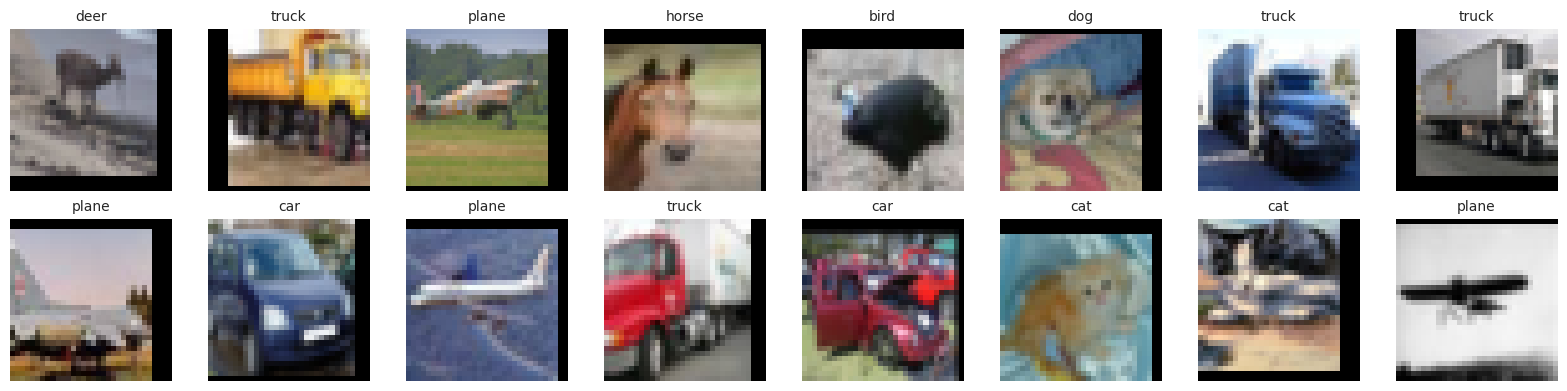


Guardado: /content/drive/MyDrive/curso_cv/outputs/sesion4/cifar10_samples.png


In [17]:
def imshow(img):
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis('off')

dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for idx, ax in enumerate(axes.flat):
    if idx < 16:
        img = images[idx] / 2 + 0.5
        ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        ax.set_title(classes[labels[idx]], fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGuardado: {OUTPUT_PATH}/cifar10_samples.png")

### 5.3 Entrenamiento

In [18]:
model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{running_loss/len(loader):.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    return running_loss/len(loader), 100.*correct/total

def evaluate(model, loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return test_loss/len(loader), 100.*correct/total

print("Funciones de entrenamiento definidas")

Funciones de entrenamiento definidas


### 5.4 Entrenar 5 Épocas

In [19]:
num_epochs = 10

train_losses, train_accs = [], []
test_losses, test_accs = [], []


print("ENTRENANDO SIMPLECNN")


for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, testloader, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"\nÉpoca {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")


print("\nEntrenamiento completado")
print(f"Mejor Test Accuracy: {max(test_accs):.2f}%")

# Guardar modelo
torch.save(model.state_dict(), f'{MODELS_PATH}/simplecnn.pth')
print(f"\nModelo guardado: {MODELS_PATH}/simplecnn.pth")

ENTRENANDO SIMPLECNN


Training: 100%|██████████| 391/391 [00:20<00:00, 19.40it/s, loss=1.6585, acc=38.40%]



Época 1/10
  Train Loss: 1.6585 | Train Acc: 38.40%
  Test Loss:  1.3435 | Test Acc:  52.26%


Training: 100%|██████████| 391/391 [00:20<00:00, 18.94it/s, loss=1.3097, acc=52.62%]



Época 2/10
  Train Loss: 1.3097 | Train Acc: 52.62%
  Test Loss:  1.1064 | Test Acc:  60.76%


...


Época 8/10
  Train Loss: 0.7869 | Train Acc: 72.54%
  Test Loss:  0.6933 | Test Acc:  75.41%


Training: 100%|██████████| 391/391 [00:21<00:00, 18.44it/s, loss=0.7568, acc=73.60%]



Época 9/10
  Train Loss: 0.7568 | Train Acc: 73.60%
  Test Loss:  0.7028 | Test Acc:  75.71%


Training: 100%|██████████| 391/391 [00:23<00:00, 16.73it/s, loss=0.7342, acc=74.55%]



Época 10/10
  Train Loss: 0.7342 | Train Acc: 74.55%
  Test Loss:  0.6627 | Test Acc:  76.95%

Entrenamiento completado
Mejor Test Accuracy: 76.95%

Modelo guardado: /content/drive/MyDrive/curso_cv/models/sesion4/simplecnn.pth


### 5.5 Visualizar Curvas

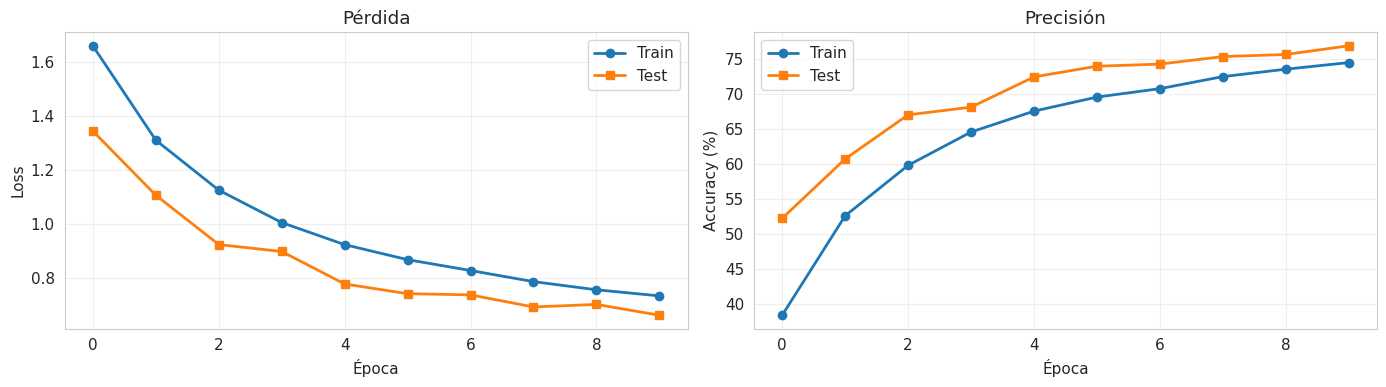

Guardado: /content/drive/MyDrive/curso_cv/outputs/sesion4/training_curves.png


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, 'o-', label='Train', linewidth=2)
ax1.plot(test_losses, 's-', label='Test', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, 'o-', label='Train', linewidth=2)
ax2.plot(test_accs, 's-', label='Test', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Precisión')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Guardado: {OUTPUT_PATH}/training_curves.png")

---
##PARTE 6: Transfer Learning
### 6.1 ResNet18 Pre-entrenado

In [21]:
# Cargar ResNet18
print("Cargando ResNet18...")
resnet = models.resnet18(pretrained=True)

# Congelar todas las capas
for param in resnet.parameters():
    param.requires_grad = False

# Reemplazar última capa
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)
resnet = resnet.to(device)

frozen = sum(p.numel() for p in resnet.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)

print("ResNet18 - Transfer Learning")
print(f"Última capa original: Linear({num_features}, 1000) → ImageNet")
print(f"Nueva última capa: Linear({num_features}, 10) → CIFAR-10")
print(f"\nParámetros congelados: {frozen:,}")
print(f"Parámetros entrenables: {trainable:,}")

Cargando ResNet18...
ResNet18 - Transfer Learning
Última capa original: Linear(512, 1000) → ImageNet
Nueva última capa: Linear(512, 10) → CIFAR-10

Parámetros congelados: 11,176,512
Parámetros entrenables: 5,130


### 6.2 Entrenar Transfer Learning

In [22]:
criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam(resnet.fc.parameters(), lr=0.001)
num_epochs_tl = 10

tl_train_accs = []
tl_test_accs = []

print("ENTRENANDO TRANSFER LEARNING (solo última capa)")

for epoch in range(num_epochs_tl):
    _, train_acc = train_epoch(resnet, trainloader, criterion_tl, optimizer_tl)
    _, test_acc = evaluate(resnet, testloader, criterion_tl)

    tl_train_accs.append(train_acc)
    tl_test_accs.append(test_acc)

    print(f"\nÉpoca {epoch+1}/{num_epochs_tl}")
    print(f"  Train Acc: {train_acc:.2f}%")
    print(f"  Test Acc:  {test_acc:.2f}%")

print("\nTransfer Learning completado")
print(f"Mejor Test Accuracy: {max(tl_test_accs):.2f}%")

torch.save(resnet.state_dict(), f'{MODELS_PATH}/resnet18_tl.pth')
print(f"\n Modelo guardado: {MODELS_PATH}/resnet18_tl.pth")

ENTRENANDO TRANSFER LEARNING (solo última capa)


Training: 100%|██████████| 391/391 [00:22<00:00, 17.59it/s, loss=1.8554, acc=34.74%]



Época 1/10
  Train Acc: 34.74%
  Test Acc:  39.15%


Training: 100%|██████████| 391/391 [00:22<00:00, 17.47it/s, loss=1.7140, acc=40.11%]



Época 2/10
  Train Acc: 40.11%
  Test Acc:  40.28%


...


Época 8/10
  Train Acc: 41.28%
  Test Acc:  41.00%


Training: 100%|██████████| 391/391 [00:23<00:00, 16.47it/s, loss=1.6780, acc=41.28%]



Época 9/10
  Train Acc: 41.28%
  Test Acc:  40.95%


Training: 100%|██████████| 391/391 [00:22<00:00, 17.03it/s, loss=1.6740, acc=41.62%]



Época 10/10
  Train Acc: 41.62%
  Test Acc:  41.24%

Transfer Learning completado
Mejor Test Accuracy: 41.24%

 Modelo guardado: /content/drive/MyDrive/curso_cv/models/sesion4/resnet18_tl.pth


---
## PARTE 7: Comparación de Enfoques
### 7.1 Tabla Comparativa

In [24]:

print("COMPARACIÓN DE RESULTADOS")

comparison = [
    ["Enfoque", "Parámetros Entrenables", "Mejor Test Acc", "Épocas"],
    ["-"*20, "-"*20, "-"*15, "-"*10],
    ["SimpleCNN", f"{sum(p.numel() for p in model.parameters()):,}", f"{max(test_accs):.2f}%", "10"],
    ["Transfer Learning", f"{trainable:,}", f"{max(tl_test_accs):.2f}%", "10"]
]

for row in comparison:
    print(f"{row[0]:<20} {row[1]:<20} {row[2]:<15} {row[3]:<10}")

print("\nTransfer Learning:")
print("  ✓ Menos parámetros entrenables")
print("  ✓ Converge más rápido")
print("  ✓ Aprovecha conocimiento de ImageNet")

COMPARACIÓN DE RESULTADOS
Enfoque              Parámetros Entrenables Mejor Test Acc  Épocas    
-------------------- -------------------- --------------- ----------
SimpleCNN            1,147,466            76.95%          10        
Transfer Learning    5,130                41.24%          10        

Transfer Learning:
  ✓ Menos parámetros entrenables
  ✓ Converge más rápido
  ✓ Aprovecha conocimiento de ImageNet


---
## Resumen de la Sesión
Hoy aprendimos:
### Parte 1: Fundamentos
- Operación de convolución desde cero
- Padding y stride
- Pooling (max, average)
### Parte 2: PyTorch
- Construir CNNs con nn.Module
- Entrenar en CIFAR-10
- Data augmentation
### Parte 3: Transfer Learning
- ResNet18 pre-entrenado
- Congelar/descongelar capas
- Fine-tuning
---
## Próxima Sesión
**Sesión 5**
- Historia de Detección de Objetos
- R-CNN, Fast R-CNN, Faster R-CNN
- Familia YOLO (v1 → v11)- Comparación de arquitecturas
---
## Recursos
- **Papers:** AlexNet (2012), ResNet (2015)
- **Tutorials:** https://pytorch.org/tutorials/